# Visualization — Poster Figures

Loads all exported artifacts and generates poster-quality figures into `artifacts/figures/`.
**Run `fraud_baseline_6d.ipynb` and `he_inference_demo.ipynb` first.**


## 1. Imports and Setup


In [1]:
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path(".").resolve()))

from src.visualization import (
    FIGURE_DIR_DEFAULT,
    plot_confusion_matrices,
    plot_he_error_scatter,
    plot_he_timing_breakdown,
    plot_model_comparison_bar,
    plot_pr_curves,
    plot_ratio_sweep,
)

PROJECT_ROOT = Path(".").resolve()
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
FIGURE_DIR   = ARTIFACT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print("Figures will be saved to:", FIGURE_DIR)

# Check all required artifacts exist
required = [
    "test_scores_6d.csv",
    "test_labels.csv",
    "extended_model_comparison.json",
    "ratio_sweep_results.json",
    "grid_search_results.json",
    "he_eval_plaintext_scores_6d.csv",
]
missing = [f for f in required if not (ARTIFACT_DIR / f).exists()]
if missing:
    print("WARNING — missing artifacts:", missing)
else:
    print("All required artifacts found.")

Figures will be saved to: /Users/elijahzyp/Desktop/CMUSPRING2026/EPS/Project/artifacts/figures
All required artifacts found.


## 2. Load Artifacts


In [2]:
test_scores_df = pd.read_csv(ARTIFACT_DIR / "test_scores_6d.csv")
y_test = test_scores_df["isFraud"].to_numpy(int)

with (ARTIFACT_DIR / "extended_model_comparison.json").open() as f:
    extended_rows = json.load(f)
extended_df = pd.DataFrame(extended_rows)
# Filter to test split metrics only (split column may not exist — rows are already test)
if "split" in extended_df.columns:
    extended_df = extended_df[extended_df["split"] == "test"].reset_index(drop=True)

he_compat_map = dict(zip(extended_df["model"], extended_df["he_compatible"]))

with (ARTIFACT_DIR / "ratio_sweep_results.json").open() as f:
    ratio_sweep_results = json.load(f)

with (ARTIFACT_DIR / "grid_search_results.json").open() as f:
    grid_search_results = json.load(f)

he_scores_df = pd.read_csv(ARTIFACT_DIR / "he_eval_plaintext_scores_6d.csv")

# HE timing (optional — only available after running he_inference_demo.ipynb with TenSEAL)
he_timing_path = ARTIFACT_DIR / "he_timing_results.json"
he_timing_available = he_timing_path.exists()
if he_timing_available:
    he_timing_df = pd.read_json(he_timing_path)
    print("HE timing data loaded:", len(he_timing_df), "rows")
else:
    print("he_timing_results.json not found — HE timing plots will be skipped.")

display(extended_df[["model", "he_compatible", "f1", "pr_auc"]])

HE timing data loaded: 12 rows


,model,he_compatible,f1,pr_auc
0,ridge_score,True,0.314007,0.733497
1,logistic_regression,True,0.786038,0.893606
2,linear_svc,True,0.744102,0.866967
3,poly2_logistic_regression,True,0.859719,0.933610
4,ridge_tuned,True,0.314007,0.733497
5,logreg_tuned,True,0.799863,0.904150
6,linear_svc_tuned,True,0.743832,0.867065
7,poly2_logreg_tuned,True,0.878161,0.963832
8,random_forest,False,0.956575,0.992970
9,gradient_boosting,False,0.882217,0.973098


## 3. Precision-Recall Curves

HE-compatible models (solid) vs non-HE baselines (dashed).


Saved pr_curves.png


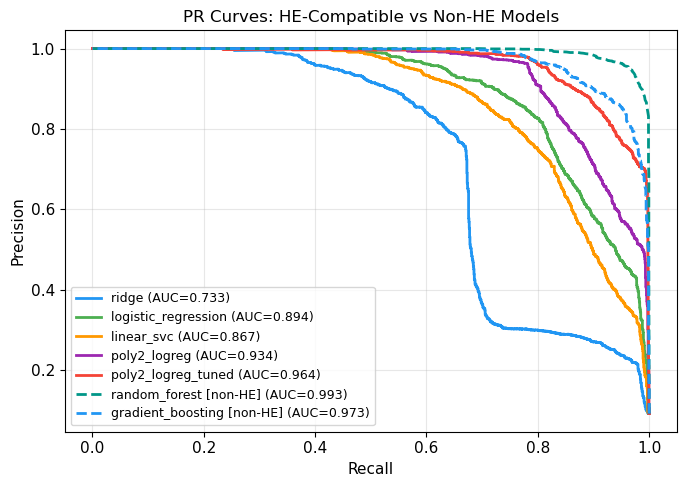

In [3]:
# Build score dict from test_scores_df
SCORE_COLS = {
    "ridge":               ("ridge_score",              True),
    "logistic_regression": ("logreg_prob",               True),
    "linear_svc":          ("linear_svc_score",          True),
    "poly2_logreg":        ("poly2_logreg_prob",         True),
    "poly2_logreg_tuned":  ("poly2_logreg_tuned_prob",   True),
    "random_forest":       ("random_forest_prob",        False),
    "gradient_boosting":   ("gradient_boosting_prob",    False),
}

model_scores_all = {
    name: (test_scores_df[col].to_numpy(), he)
    for name, (col, he) in SCORE_COLS.items()
    if col in test_scores_df.columns
}

fig_pr = plot_pr_curves(
    model_scores_all, y_test,
    title="PR Curves: HE-Compatible vs Non-HE Models",
    save_path=FIGURE_DIR / "pr_curves.png",
)
print("Saved pr_curves.png")

## 4. Confusion Matrices


Saved confusion_matrices.png


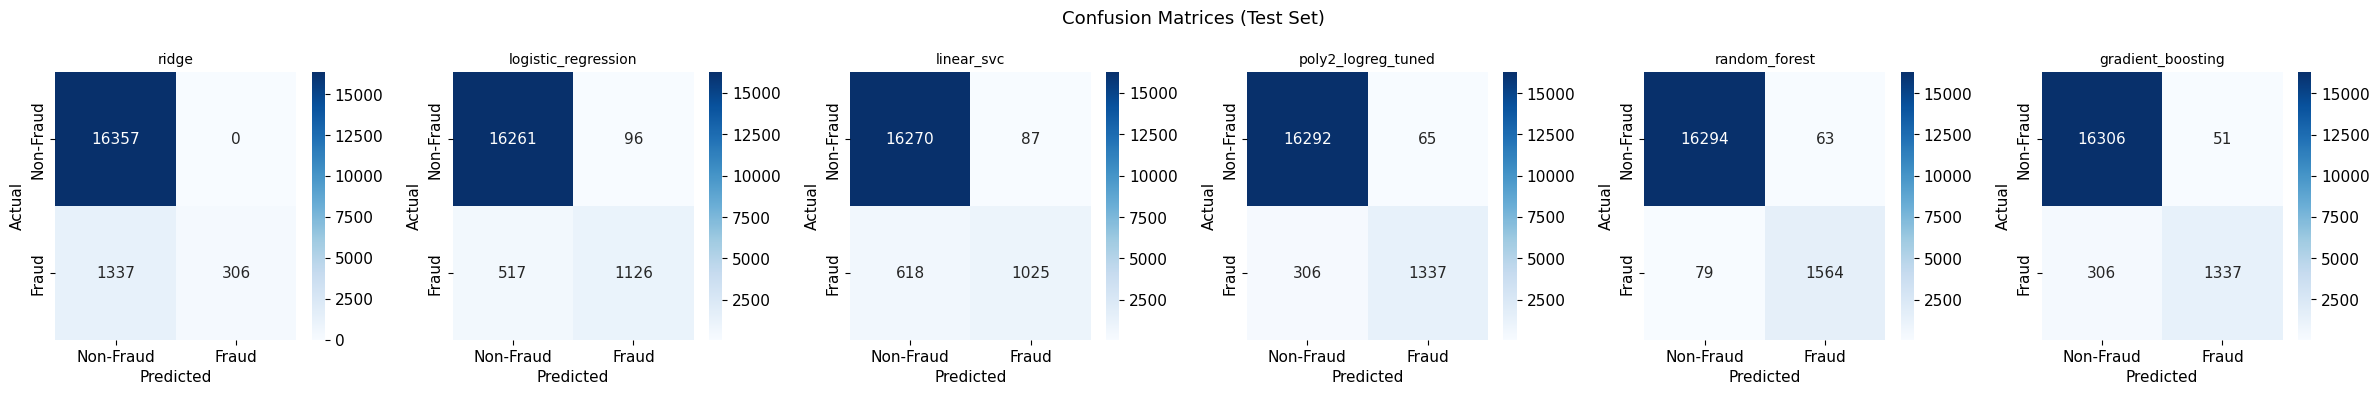

In [4]:
PRED_COLS = {
    "ridge":               ("ridge_score",             lambda s: (s >= 0.0).astype(int)),
    "logistic_regression": ("logreg_prob",              lambda p: (p >= 0.5).astype(int)),
    "linear_svc":          ("linear_svc_score",         lambda s: (s >= 0.0).astype(int)),
    "poly2_logreg_tuned":  ("poly2_logreg_tuned_prob",  lambda p: (p >= 0.5).astype(int)),
    "random_forest":       ("random_forest_prob",       lambda p: (p >= 0.5).astype(int)),
    "gradient_boosting":   ("gradient_boosting_prob",   lambda p: (p >= 0.5).astype(int)),
}

model_preds = {
    name: fn(test_scores_df[col].to_numpy())
    for name, (col, fn) in PRED_COLS.items()
    if col in test_scores_df.columns
}

fig_cm = plot_confusion_matrices(
    model_preds, y_test,
    save_path=FIGURE_DIR / "confusion_matrices.png",
)
print("Saved confusion_matrices.png")

## 5. Model Performance Comparison Bar Chart


Saved model_comparison_bar.png


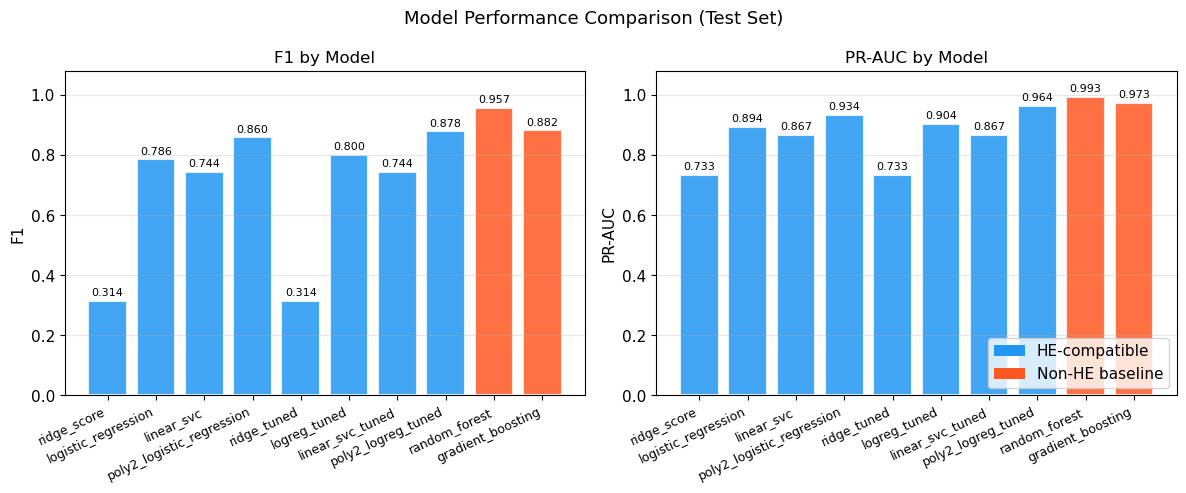

In [5]:
fig_bar = plot_model_comparison_bar(
    extended_df,
    he_compat_map=he_compat_map,
    save_path=FIGURE_DIR / "model_comparison_bar.png",
)
print("Saved model_comparison_bar.png")

## 6. Sampling Ratio Sweep


Saved ratio_sweep.png


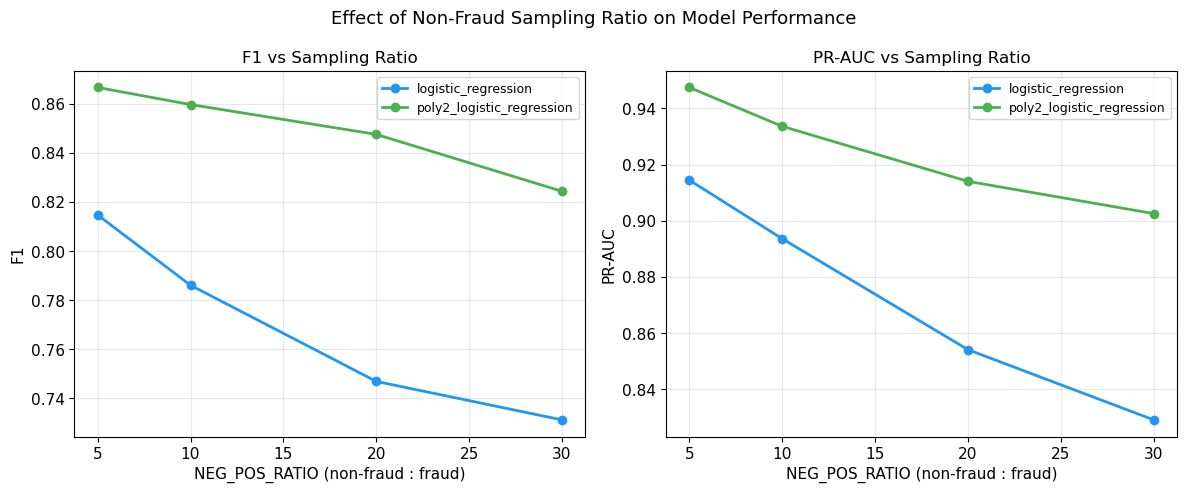

In [6]:
fig_ratio = plot_ratio_sweep(
    ratio_sweep_results,
    save_path=FIGURE_DIR / "ratio_sweep.png",
)
print("Saved ratio_sweep.png")

## 7. HE Timing Breakdown


Saved he_timing_breakdown.png


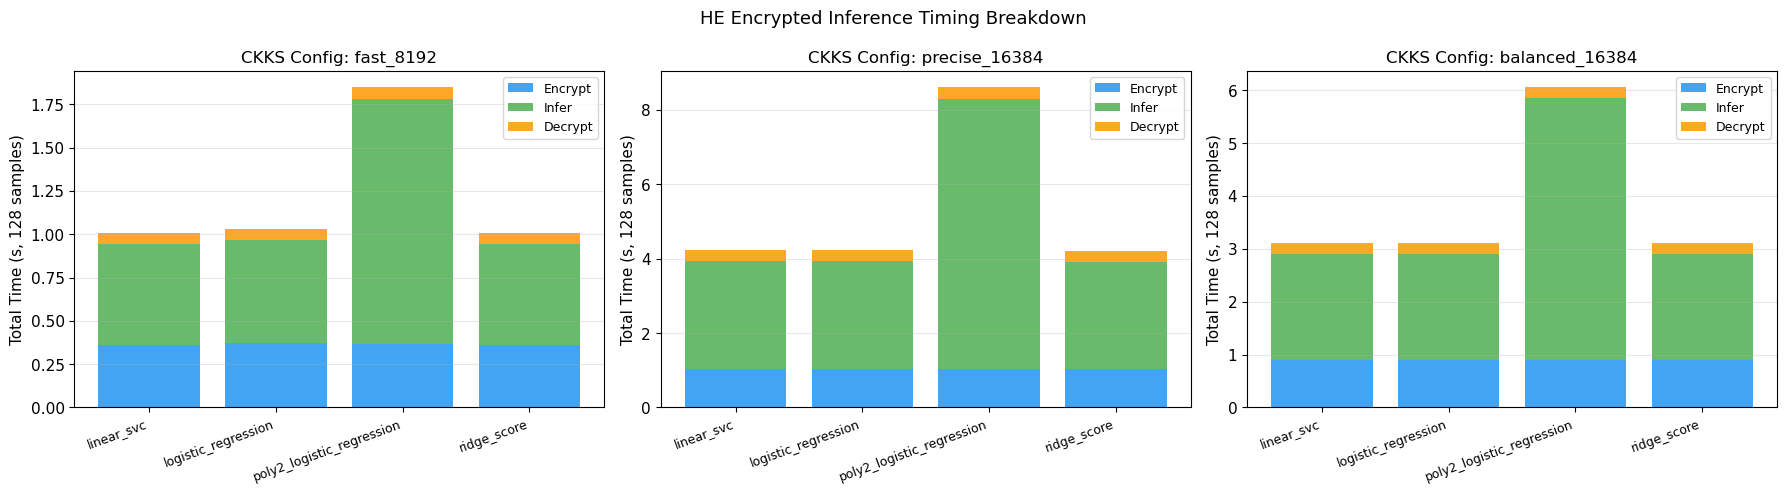

In [7]:
if he_timing_available:
    fig_timing = plot_he_timing_breakdown(
        he_timing_df,
        save_path=FIGURE_DIR / "he_timing_breakdown.png",
    )
    print("Saved he_timing_breakdown.png")
else:
    print("Skipped — run he_inference_demo.ipynb with TenSEAL first.")

## 7b. HE vs Plaintext Inference Overhead

Measure plaintext inference time on the same 128-sample HE eval subset,
then compare against HE timing to show the per-sample latency overhead and overhead factor (×N).


/opt/anaconda3/envs/prompt_engineering/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/prompt_engineering/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/prompt_engineering/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PolynomialFea

Plaintext inference times (128 samples, avg over 20 reps):
  ridge_score: 0.002 ms total  (0.02 µs/sample)
  logistic_regression: 0.003 ms total  (0.02 µs/sample)
  linear_svc: 0.034 ms total  (0.27 µs/sample)
  poly2_logistic_regression: 0.041 ms total  (0.32 µs/sample)


Saved he_vs_plaintext_overhead.png


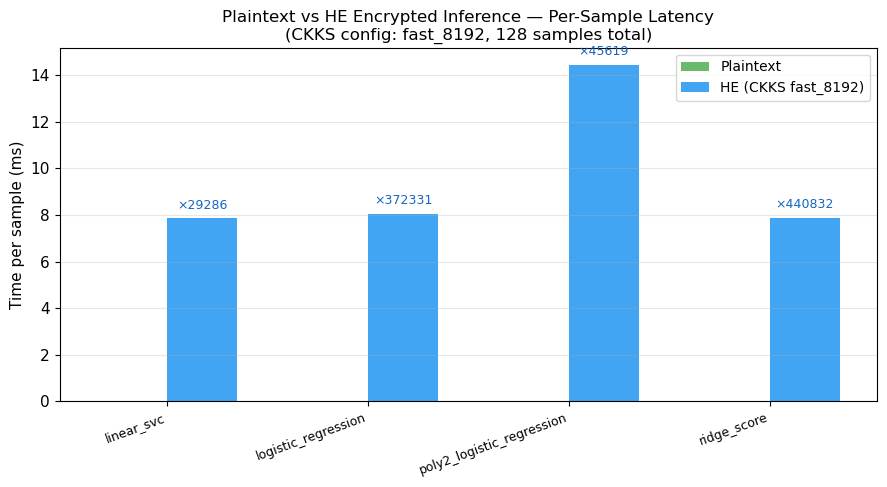

In [8]:
import time
import pickle
import numpy as np
from scipy.special import expit
from sklearn.preprocessing import PolynomialFeatures
from src.visualization import plot_he_vs_plaintext_overhead

# Load HE eval features and model weights
he_features_df = pd.read_csv(ARTIFACT_DIR / "he_eval_scaled_features_6d.csv")

with (ARTIFACT_DIR / "baseline_6d_ridge.pkl").open("rb") as _f:
    _ridge = pickle.load(_f)
with (ARTIFACT_DIR / "baseline_6d_logreg.pkl").open("rb") as _f:
    _logreg = pickle.load(_f)
with (ARTIFACT_DIR / "linear_svc_model.pkl").open("rb") as _f:
    _svc = pickle.load(_f)
with (ARTIFACT_DIR / "poly2_logreg_model.pkl").open("rb") as _f:
    _p2 = pickle.load(_f)
with (ARTIFACT_DIR / "poly2_transformer.pkl").open("rb") as _f:
    _poly = pickle.load(_f)

X_he = he_features_df.to_numpy(dtype=float)
X_he_poly = _poly.transform(X_he)
N_REPS = 20  # repeat to get stable timing

def time_fn(fn, reps=N_REPS):
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps

plaintext_times = {
    "ridge_score":              time_fn(lambda: X_he @ _ridge['weights'] + _ridge['bias']),
    "logistic_regression":      time_fn(lambda: expit(X_he @ _logreg['weights'] + _logreg['bias'])),
    "linear_svc":               time_fn(lambda: _svc.decision_function(X_he)),
    "poly2_logistic_regression": time_fn(lambda: _p2.predict_proba(X_he_poly)[:, 1]),
}

print("Plaintext inference times (128 samples, avg over 20 reps):")
for m, t in plaintext_times.items():
    print(f"  {m}: {t*1000:.3f} ms total  ({t/128*1e6:.2f} µs/sample)")

if he_timing_available:
    fig_overhead = plot_he_vs_plaintext_overhead(
        he_timing_df,
        plaintext_times=plaintext_times,
        config="fast_8192",
        n_samples=128,
        save_path=FIGURE_DIR / "he_vs_plaintext_overhead.png",
    )
    print("Saved he_vs_plaintext_overhead.png")
else:
    print("Skipped — run he_inference_demo.ipynb with TenSEAL first.")

## 8. Plaintext vs Encrypted Score Scatter


Note: using plaintext scores as placeholder (run HE demo to get encrypted scores).


Saved he_error_scatter.png


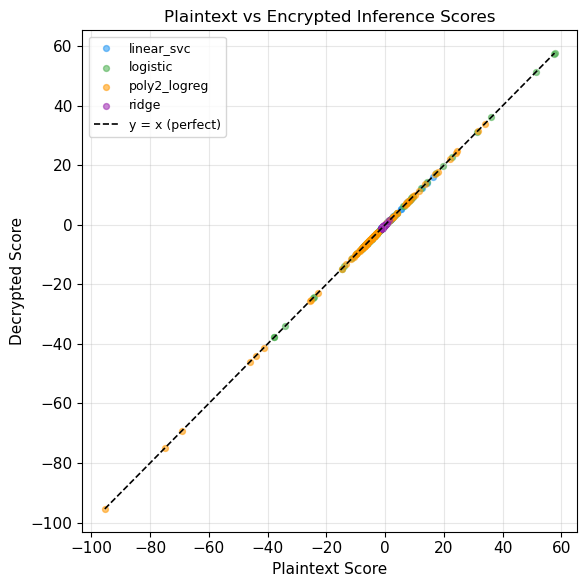

In [9]:
# Reshape he_eval plaintext scores into long format for scatter plot
score_label_map = {
    "ridge":        "ridge_raw_score",
    "logistic":     "logistic_raw_logit",
    "linear_svc":   "linear_svc_decision",
    "poly2_logreg": "poly2_logreg_raw_score",
}

if he_timing_available:
    # Build long-format df from he_timing_df (has per-sample results available from batch demo)
    # Fallback: use plaintext scores vs themselves (zero error, for illustration)
    pass

# Use plaintext reference scores (self-consistency check)
he_scatter_rows = []
for model_name, col in score_label_map.items():
    if col in he_scores_df.columns:
        for score in he_scores_df[col]:
            he_scatter_rows.append({
                "model_name": model_name,
                "plaintext_score": float(score),
                "decrypted_score": float(score),  # placeholder; replace with actual HE decrypted scores
            })

he_scatter_df = pd.DataFrame(he_scatter_rows)

# If actual HE results JSON exists, load and use those
he_batch_path = ARTIFACT_DIR / "he_batch_results.json"
if he_batch_path.exists():
    with he_batch_path.open() as _f:
        he_batch = json.load(_f)
    he_scatter_df = pd.DataFrame(he_batch)
    print("Using actual HE decrypted scores from he_batch_results.json")
else:
    print("Note: using plaintext scores as placeholder (run HE demo to get encrypted scores).")

fig_scatter = plot_he_error_scatter(
    he_scatter_df,
    save_path=FIGURE_DIR / "he_error_scatter.png",
)
print("Saved he_error_scatter.png")

## 9. Figure Summary


In [10]:
print("Generated figures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  {p.name}  ({p.stat().st_size // 1024} KB)")

Generated figures:
  confusion_matrices.png  (232 KB)
  he_error_scatter.png  (175 KB)
  he_timing_breakdown.png  (218 KB)
  he_vs_plaintext_overhead.png  (177 KB)
  model_comparison_bar.png  (266 KB)
  pr_curves.png  (244 KB)
  ratio_sweep.png  (272 KB)
